# Projet : Détection de biais dans un modèle de recommandation (Adult Income)
Ce notebook présente une approche d’analyse des biais dans un modèle
de classification binaire appliqué à un jeu de données réel.
Le modèle de machine learning est utilisé comme outil
afin d’illustrer des concepts d’estimation et de tests statistiques.

## Objectif
1. **Entraîner** un modèle de classification binaire (régression logistique) pour prédire `income` (<=50K / >50K).
2. **Mesurer** un biais potentiel entre deux groupes (ici `gender`: Male vs Female) via :
   - **Estimation** du taux d’acceptation (prédictions positives)
   - **Inférence** : Intervalle de confiance (bootstrap)
   - **Test d’hypothèse** : Z-test sur proportions
3. **Visualiser** les résultats (barplot, bootstrap, ROC).

> Remarque : on **n’utilise pas** la variable sensible `gender` dans les features d’entraînement, afin d’observer si un biais apparaît malgré tout (corrélations indirectes).

## 1. Imports

In [3]:
# Cellule 1 — Imports
# Librairies de manipulation de données
import pandas as pd
import numpy as np

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve

# Statistiques (tests sur proportions)
from statsmodels.stats.proportion import proportions_ztest

# Visualisation
import matplotlib.pyplot as plt
# Test d'indépendance (robustesse)
from scipy.stats import chi2_contingency


## 2. Chargement des données

In [27]:
# Cellule 2 — Load dataset + preview
df = pd.read_csv("./data/adult.csv")

print("Shape:", df.shape)
df.head()


Shape: (48842, 15)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,gender,capital-gain,capital-loss,hours-per-week,native-country,income
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,Male,0,0,40,United-States,<=50K
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,Male,0,0,50,United-States,<=50K
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,Male,0,0,40,United-States,>50K
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,Male,7688,0,40,United-States,>50K
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,Female,0,0,30,United-States,<=50K


## 3. Compréhension rapide du dataset

In [5]:
# Cellule 3 — Columns + quick checks
# On vérifie les colonnes et les modalités des variables clés.
print(df.columns.tolist())

print("\nUnique values in gender:", df["gender"].unique())
print("Unique values in income:", df["income"].unique())


['age', 'workclass', 'fnlwgt', 'education', 'educational-num', 'marital-status', 'occupation', 'relationship', 'race', 'gender', 'capital-gain', 'capital-loss', 'hours-per-week', 'native-country', 'income']

Unique values in gender: ['Male' 'Female']
Unique values in income: ['<=50K' '>50K']


## 4. Définition de la cible (y) et de l’attribut sensible (S)

In [6]:
# Cellule 4 — Target (y) + Sensitive attribute (S)
# Nettoyage léger des libellés (espaces) puis définition :
# - y : cible binaire (income >50K ?)
# - S : attribut sensible (gender)
# income: '>50K' => 1, '<=50K' => 0
df["income"] = df["income"].astype(str).str.strip()
df["income"] = df["income"].apply(lambda x: 1 if x == ">50K" else 0)

y = df["income"]      # target binaire
S = df["gender"]      # attribut sensible (Male/Female)

print("y distribution:")
print(y.value_counts())

print("\nSensitive attribute distribution:")
print(S.value_counts())


y distribution:
income
0    37155
1    11687
Name: count, dtype: int64

Sensitive attribute distribution:
gender
Male      32650
Female    16192
Name: count, dtype: int64


## 5. Préparation des features (X)

In [7]:
# Cellule 5 — Prepare features X
# On retire :
# - 'income' (cible)
# - 'gender' (variable sensible) pour ne pas l'utiliser à l'entraînement
X = df.drop(columns=["income", "gender"])

print("Shape of X:", X.shape)
X.head()


Shape of X: (48842, 13)


,age,workclass,fnlwgt,education,educational-num,marital-status,occupation,relationship,race,capital-gain,capital-loss,hours-per-week,native-country
0,25,Private,226802,11th,7,Never-married,Machine-op-inspct,Own-child,Black,0,0,40,United-States
1,38,Private,89814,HS-grad,9,Married-civ-spouse,Farming-fishing,Husband,White,0,0,50,United-States
2,28,Local-gov,336951,Assoc-acdm,12,Married-civ-spouse,Protective-serv,Husband,White,0,0,40,United-States
3,44,Private,160323,Some-college,10,Married-civ-spouse,Machine-op-inspct,Husband,Black,7688,0,40,United-States
4,18,?,103497,Some-college,10,Never-married,?,Own-child,White,0,0,30,United-States


## 6. Nettoyage des valeurs manquantes ('?')

In [8]:
# Cellule 6 — Handle missing values '?'
# Dans ce dataset, certaines valeurs manquantes sont notées '?'.
X = X.replace("?", pd.NA)

print("Missing values before cleaning (top 5):")
print(X.isna().sum().sort_values(ascending=False).head())

# On supprime les lignes qui contiennent au moins une valeur manquante
mask = X.notna().all(axis=1)
X = X.loc[mask]
y = y.loc[mask]
S = S.loc[mask]

print("\nShape after removing missing values:", X.shape)


Missing values before cleaning (top 5):
occupation        2809
workclass         2799
native-country     857
age                  0
fnlwgt               0
dtype: int64

Shape after removing missing values: (45222, 13)


## 7. Encodage des variables catégorielles (One-Hot)

In [9]:
# Cellule 7 — One-hot encoding
# La régression logistique nécessite des variables numériques.
# get_dummies transforme les colonnes catégorielles en indicatrices 0/1.
X = pd.get_dummies(X, drop_first=True)

print("Shape after one-hot encoding:", X.shape)
X.head()


Shape after one-hot encoding: (45222, 95)


,age,fnlwgt,educational-num,capital-gain,capital-loss,hours-per-week,workclass_Local-gov,workclass_Private,workclass_Self-emp-inc,workclass_Self-emp-not-inc,...,native-country_Portugal,native-country_Puerto-Rico,native-country_Scotland,native-country_South,native-country_Taiwan,native-country_Thailand,native-country_Trinadad&Tobago,native-country_United-States,native-country_Vietnam,native-country_Yugoslavia
0,25,226802,7,0,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
1,38,89814,9,0,0,50,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
2,28,336951,12,0,0,40,True,False,False,False,...,False,False,False,False,False,False,False,True,False,False
3,44,160323,10,7688,0,40,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False
5,34,198693,6,0,0,30,False,True,False,False,...,False,False,False,False,False,False,False,True,False,False


## 8. Split Train/Test

In [10]:
# Cellule 8 — Train / Test split
# On garde 30% en test pour avoir assez de données pour l'analyse par groupe (Male/Female).
X_train, X_test, y_train, y_test, S_train, S_test = train_test_split(
    X, y, S,
    test_size=0.30,
    random_state=42,
    stratify=y  # conserve la proportion de classes entre train et test
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)

print("\nTarget distribution (train):")
print(y_train.value_counts(normalize=True))

print("\nTarget distribution (test):")
print(y_test.value_counts(normalize=True))


Train shape: (31655, 95)
Test shape: (13567, 95)

Target distribution (train):
income
0    0.75214
1    0.24786
Name: proportion, dtype: float64

Target distribution (test):
income
0    0.752193
1    0.247807
Name: proportion, dtype: float64


## 9. Machine Learning : Régression Logistique
On utilise une régression logistique pour estimer la probabilité
d’une décision positive à partir des variables explicatives.
Le modèle combine ces variables pour produire un score,
qui est ensuite transformé en une valeur comprise entre 0 et 1,
interprétée comme une probabilité.

Les paramètres du modèle sont estimés en minimisant une fonction de perte
(log-loss) à l’aide d’un algorithme d’optimisation numérique.

In [11]:
# Cellule 9 — Train Logistic Regression + performance
# Remarque : un "ConvergenceWarning" peut apparaître (dataset + one-hot => beaucoup de variables).
# Ce n'est pas bloquant pour notre objectif (analyse du biais), mais on peut augmenter max_iter.

model = LogisticRegression(
    max_iter=5000,
    solver="lbfgs",
    n_jobs=-1
)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)                # classes 0/1
y_proba = model.predict_proba(X_test)[:, 1]   # probabilité de la classe 1

# Performance globale
acc = accuracy_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_proba)

print(f"Accuracy: {acc:.4f}")
print(f"AUC     : {auc:.4f}")


Accuracy: 0.8401
AUC     : 0.8969


## 10. Inférence statistique : taux d’acceptation par genre

On compare les taux de décisions positives prédits par le modèle
pour les groupes Male et Female.

On définit :
- p_M : taux de prédictions positives chez les Male
- p_F : taux de prédictions positives chez les Female

La différence de taux d’acceptation est :
Δ = p_M − p_F


In [15]:
# Cellule 10 — Taux d’acceptation par groupe (Male vs Female)
# Taux d’acceptation = proportion de prédictions positives (y_pred=1) dans chaque groupe.

# Masques de groupes (après nettoyage des chaînes)
male_mask = (S_test == "Male").values
female_mask = (S_test == "Female").values

p_hat_male = np.mean(y_pred[male_mask])
p_hat_female = np.mean(y_pred[female_mask])
diff_hat = p_hat_male - p_hat_female

print(f"Taux d’acceptation (Male)     : {p_hat_male:.4f}  (n={male_mask.sum()})")
print(f"Taux d’acceptation (Female)   : {p_hat_female:.4f}  (n={female_mask.sum()})")
print(f"Différence estimée Δ (M-F)    : {diff_hat:.4f}")


Taux d’acceptation (Male)     : 0.2597  (n=9140)
Taux d’acceptation (Female)   : 0.0806  (n=4427)
Différence estimée Δ (M-F)    : 0.1791


## 11. Bootstrap : Intervalle de Confiance (IC 95%)
On approxime la distribution de `diff_hat` par rééchantillonnage dans chaque groupe (avec remise).

In [16]:
# Cellule 11 — Bootstrap pour 4 du biais (Male - Female)

np.random.seed(42)  # reproductibilité

B = 2000  # nombre de rééchantillonnages bootstrap
diff_boot = []

male_idx = np.where(male_mask)[0]
female_idx = np.where(female_mask)[0]

for _ in range(B):
    sample_male = np.random.choice(male_idx, size=len(male_idx), replace=True)
    sample_female = np.random.choice(female_idx, size=len(female_idx), replace=True)

    p_m = np.mean(y_pred[sample_male])
    p_f = np.mean(y_pred[sample_female])
    diff_boot.append(p_m - p_f)

diff_boot = np.array(diff_boot)

ci_low = np.percentile(diff_boot, 2.5)
ci_high = np.percentile(diff_boot, 97.5)

print("IC 95% pour la différence (Male - Female):")
print("[", ci_low, ",", ci_high, "]")

# Interprétation rapide :
# - si 0 ∈ IC : la différence peut être due au hasard (pas de preuve forte)
# - si 0 ∉ IC : différence statistiquement significative


IC 95% pour la différence (Male - Female):
[ 0.16683179393506825 , 0.19155817828137361 ]


## 12. Test d’hypothèse : Z-test des proportions

On teste si la différence de taux de décisions positives entre les groupes
Male et Female peut s’expliquer par le hasard.

On définit :
- p_M : taux de prédictions positives chez les Male
- p_F : taux de prédictions positives chez les Female

Hypothèses du test :
- H0 : p_M = p_F
- H1 : p_M ≠ p_F

On utilise un test Z sur deux proportions avec un seuil de significativité
α = 0.05.


In [17]:
# Cellule 12 — Z-test sur proportions

success_male = np.sum(y_pred[male_mask])
success_female = np.sum(y_pred[female_mask])

n_male = np.sum(male_mask)
n_female = np.sum(female_mask)

count = np.array([success_male, success_female])
nobs = np.array([n_male, n_female])

z_stat, p_value = proportions_ztest(count, nobs)

print("Z-statistic:", z_stat)
print("p-value:", p_value)

# Décision (seuil alpha=0.05):
# - p_value < 0.05 => rejet de H0 => différence significative


Z-statistic: 24.392710800748592
p-value: 2.0436301643886637e-131


### Synthèse par groupe et test χ²

Cette section présente une synthèse des décisions du modèle par groupe
(Male et Female).  
Un test du χ² d’indépendance est utilisé pour évaluer la dépendance
entre le groupe et la décision prédite.

Le Disparate Impact est également calculé comme le ratio des taux
d’acceptation entre les deux groupes.


In [18]:
# Cellule 12bis — Synthèse par groupe + test χ² (robustesse)

# Tableau de contingence : lignes = groupe, colonnes = décision (0/1)
# Pour le χ², on utilise une table 2x2 :
#   [#pred=1, #pred=0] pour Male et Female
table = np.array([
    [success_male,   n_male - success_male],
    [success_female, n_female - success_female]
])

chi2, chi2_p, dof, expected = chi2_contingency(table)

# Disparate Impact (ratio des taux) — souvent utilisé en fairness (règle des 80% en pratique)
# Ici : taux(Female)/taux(Male). (Valeur proche de 1 => moins de disparité)
disparate_impact = (p_hat_female / p_hat_male) if p_hat_male > 0 else np.nan

summary = pd.DataFrame({
    "Groupe": ["Male", "Female"],
    "n": [int(n_male), int(n_female)],
    "Pred=1 (count)": [int(success_male), int(success_female)],
    "Taux acceptation (Pred=1)": [p_hat_male, p_hat_female],
})

display(summary)

print("\n--- Indicateurs clés ---")
print(f"Différence Δ = Male - Female : {diff_hat:.4f}")
print(f"IC 95% (bootstrap)           : [{ci_low:.4f}, {ci_high:.4f}]")
print(f"Z-test (2 proportions)       : z={z_stat:.3f}, p={p_value:.3g}")
print(f"Chi² (indépendance)          : chi2={chi2:.3f}, p={chi2_p:.3g}")
print(f"Disparate Impact (F/M)       : {disparate_impact:.3f}")


,Groupe,n,Pred=1 (count),Taux acceptation (Pred=1)
0,Male,9140,2374,0.259737
1,Female,4427,357,0.080642



--- Indicateurs clés ---
Différence Δ = Male - Female : 0.1791
IC 95% (bootstrap)           : [0.1668, 0.1916]
Z-test (2 proportions)       : z=24.393, p=2.04e-131
Chi² (indépendance)          : chi2=593.891, p=3.57e-131
Disparate Impact (F/M)       : 0.310


## 13. Visualisations
Les figures ci-dessous illustrent (i) l’écart de taux d’acceptation par groupe, (ii) l’incertitude sur cet écart via bootstrap,
et (iii) la performance globale via la courbe ROC.

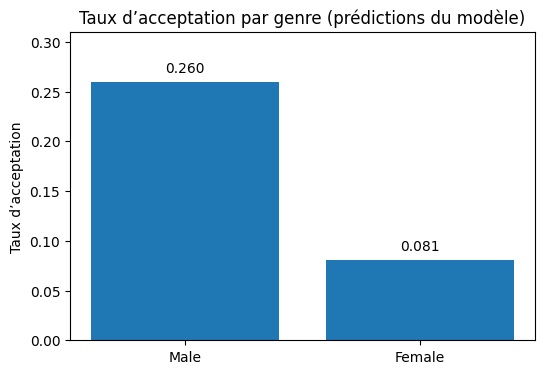

In [19]:
# Cellule 13 — Bar plot des taux d’acceptation
labels = ["Male", "Female"]
rates = [p_hat_male, p_hat_female]

plt.figure(figsize=(6,4))
plt.bar(labels, rates)
plt.ylabel("Taux d’acceptation")
plt.title("Taux d’acceptation par genre (prédictions du modèle)")
plt.ylim(0, max(rates) + 0.05)

for i, v in enumerate(rates):
    plt.text(i, v + 0.01, f"{v:.3f}", ha="center")

plt.show()


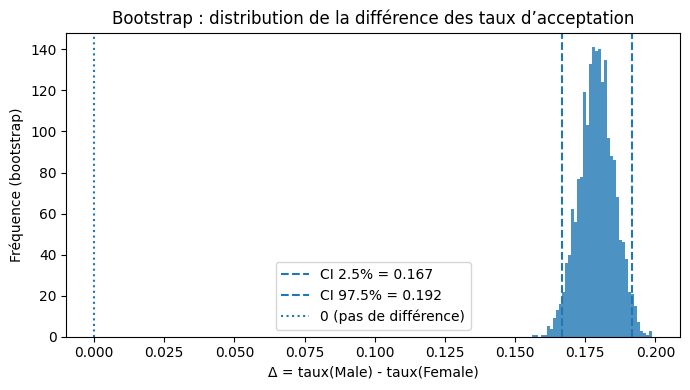

In [23]:
# Cellule 14 — Distribution bootstrap + IC (incertitude sur Δ)

plt.figure(figsize=(7,4))
plt.hist(diff_boot, bins=40, alpha=0.8)
plt.axvline(ci_low, linestyle="--", label=f"CI 2.5% = {ci_low:.3f}")
plt.axvline(ci_high, linestyle="--", label=f"CI 97.5% = {ci_high:.3f}")
plt.axvline(0, linestyle=":", label="0 (pas de différence)")
plt.xlabel("Δ = taux(Male) - taux(Female)")
plt.ylabel("Fréquence (bootstrap)")
plt.title("Bootstrap : distribution de la différence des taux d’acceptation")
plt.legend()
plt.tight_layout()
plt.show()


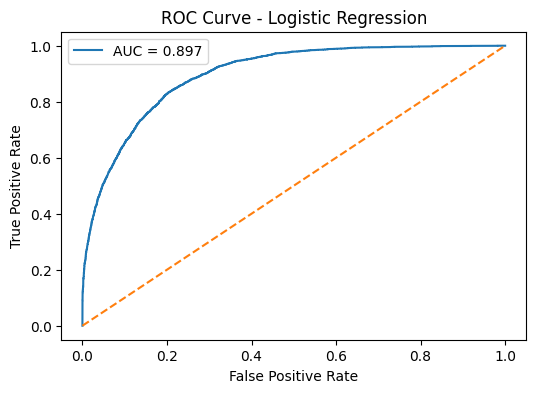

In [ ]:
# Cellule 15 — Courbe ROC (performance globale)
fpr, tpr, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(6,4))
plt.plot(fpr, tpr, label=f"AUC = {auc:.3f}")
plt.plot([0,1], [0,1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend()
plt.show()


## 14. Conclusion (à copier dans le rapport)

- Le modèle atteint une **bonne performance** (AUC/Accuracy).
- Cependant, l’analyse par groupes montre un **écart important** du taux d’acceptation entre *Male* et *Female*.
- L’**IC 95%** (bootstrap) n’inclut pas 0 et le **Z-test** donne une p-value extrêmement faible ⇒ **différence statistiquement significative**.


